# Part B: Training and Using Word Embeddings

In [ ]:
!pip install gensim
!pip install nltk

In [ ]:
# Import required libary

from gensim.models import Word2Vec
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE
import nltk
from nltk.corpus import brown
import numpy as np

## Task B.1: Training Word2Vec
1. Load your chosen text corpus and perform basic preprocessing (tokenization, lowercasing).
2. Use the Gensim library to train a Word2Vec model (e.g., Skip-Gram architecture) on the corpus.
Hyperparameters: Set the embedding dimension (e.g., vector_size=100) and the window size.

In [ ]:
nltk.download('brown')
corpus_raw = brown.words()
processed_corpus = [word.lower() for word in corpus_raw]
sentences = brown.sents()
processed_sentences = [[word.lower() for word in sentence] for sentence in sentences]

print(f"Original words count: {len(corpus_raw)}")
print(f"Processed words (first 10): {processed_corpus[:10]}")
print(f"Processed sentences (first sentence): {processed_sentences[0]}")

[nltk_data] Downloading package brown to /root/nltk_data...
[nltk_data]   Package brown is already up-to-date!


Original words count: 1161192
Processed words (first 10): ['the', 'fulton', 'county', 'grand', 'jury', 'said', 'friday', 'an', 'investigation', 'of']
Processed sentences (first sentence): ['the', 'fulton', 'county', 'grand', 'jury', 'said', 'friday', 'an', 'investigation', 'of', "atlanta's", 'recent', 'primary', 'election', 'produced', '``', 'no', 'evidence', "''", 'that', 'any', 'irregularities', 'took', 'place', '.']


In [ ]:
model = Word2Vec(sentences=processed_sentences, vector_size=100, window=5, min_count=1, workers=4, sg=1)

print(f"Word2Vec model trained. Vocabulary size: {len(model.wv)}")
print(f"Embedding dimension: {model.wv.vector_size}")

# model.save("word2vec_brown.model")

Word2Vec model trained. Vocabulary size: 49815
Embedding dimension: 100


## Task B.2: Exploring Semantic Similarity Verify that the learned vectors capture meaning.
1. Use the trained model's .most_similar() method to find the top 5 words most similar to a seed word (e.g., "king," "python," or a domain-specific term from your corpus).
2. Demonstrate the famous analogy task using vector arithmetic: vector('king') - vector('man') + vector('woman') and display the most similar result (which should ideally be 'queen').


In [ ]:
print(f"Top 5 similar to 'king': {model.wv.most_similar('king', topn=5)}")

analogy_result = model.wv.most_similar(positive=['king', 'woman'], negative=['man'], topn=1)
print(f"Analogy Result (king - man + woman): {analogy_result}")

Top 5 similar to 'king': [('quiney', 0.9147241115570068), ('martin', 0.9092821478843689), ('jackson', 0.9089088439941406), ('lieutenant', 0.908044159412384), ('jane', 0.9074293375015259)]
Analogy Result (king - man + woman): [('packard', 0.8549816012382507)]


## Task B.3: Visualization and Comparison (Mini-Report) Embeddings live in high-dimensional space (e.g., 100D), making them impossible to view directly.
1. Select a set of 50 common words from your vocabulary.
2. Use a dimensionality reduction technique like t-SNE (from scikit-learn) to project the 100D vectors down to 2D.
3. Plot the 2D results using matplotlib. Analyze the plot: Do semantically related words cluster together?

In [ ]:
common_words = model.wv.index_to_key[:50]
print(f"Selected 50 common words: {common_words}")

Selected 50 common words: ['the', ',', '.', 'of', 'and', 'to', 'a', 'in', 'that', 'is', 'was', 'he', 'for', '``', "''", 'it', 'with', 'as', 'his', 'on', 'be', ';', 'at', 'by', 'i', 'this', 'had', '?', 'not', 'are', 'but', 'from', 'or', 'have', 'an', 'they', 'which', '--', 'one', 'you', 'were', 'her', 'all', 'she', 'there', 'would', 'their', 'we', 'him', 'been']


In [ ]:
word_vectors = np.array([model.wv[word] for word in common_words])
print(f"Shape of word vectors for common words: {word_vectors.shape}")

Shape of word vectors for common words: (50, 100)


In [ ]:
tsne = TSNE(n_components=2, random_state=42, perplexity=10)
vectors_2d = tsne.fit_transform(word_vectors)
print(f"Shape of 2D vectors after t-SNE: {vectors_2d.shape}")

Shape of 2D vectors after t-SNE: (50, 2)


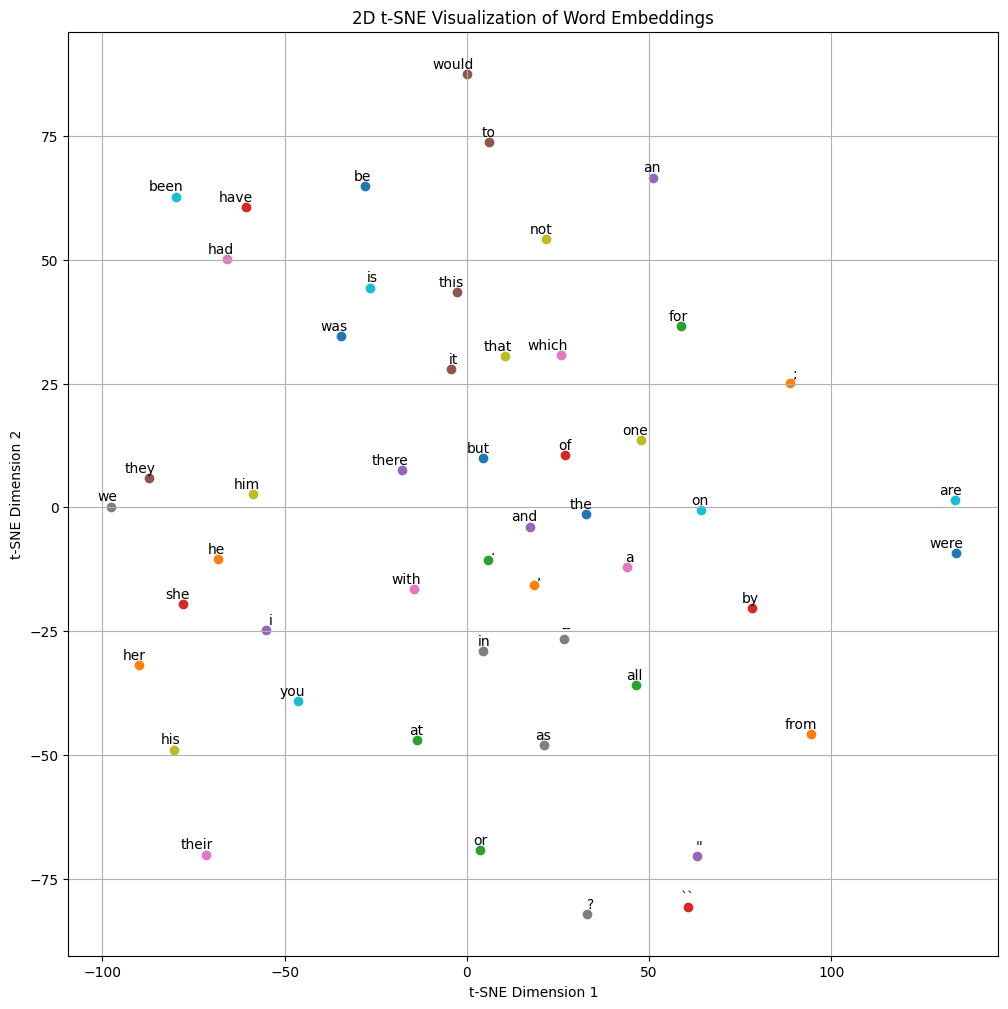

In [ ]:
plt.figure(figsize=(12, 12))
for i, word in enumerate(common_words):
    plt.scatter(vectors_2d[i, 0], vectors_2d[i, 1])
    plt.annotate(word, xy=(vectors_2d[i, 0], vectors_2d[i, 1]), xytext=(5, 2),
                 textcoords='offset points', ha='right', va='bottom')
plt.title('2D t-SNE Visualization of Word Embeddings')
plt.xlabel('t-SNE Dimension 1')
plt.ylabel('t-SNE Dimension 2')
plt.grid(True)
plt.show()